# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-09: HR PhysFormer Training 

### What this notebook does
Trains PhysFormer (Temporal-Difference Transformer, Yu et al., CVPR 2022) on the three
preprocessed datasets (MCD + UBFC-rPPG + DLCN) as the second architecture in the
screen-then-tune plan. Same pipeline as NB_P3_08 (PhysNet): committed loader, subject-wise
split, temporal-rescale + hflip augmentation, cardiac_sqi soft-weighting, neg-Pearson +
frequency loss, and the honest per-dataset / resting / Bland-Altman evaluation. Changes vs
NB_P3_08: the model (+ its paper-default hyperparameters) and multi-clip-per-recording
sampling. Compared against the PhysNet baseline (val HR MAE ~8).

### PhysFormer recipe (CVPR 2022 paper)
- Optimizer: Adam, lr 1e-4, weight decay 5e-5.
- Architecture: N=12 layers, h=4 heads, D=96, D'=144, theta=0.7, gra_sharp (tau)=2.0.
- Input: 160xHxW clips; augmentation = horizontal flip + temporal up/down-sampling
  (== our temporal-rescale aug). PhysFormer's stem needs 128x128, so our 72x72 clips are
  upsampled to 128 inside pf_forward.
- Loss: the paper adds a frequency cross-entropy + label-distribution term with a
  curriculum weight; for this first-pass SCREEN we reuse our neg-Pearson + frequency-match
  loss to keep it comparable across architectures. The native PhysFormer frequency-CE is a
  tuning-stage add.

### Implementation note
PhysFormer is used from the official repo (ZitongYu/PhysFormer) - imported as a package
(model.Physformer) so its relative imports resolve - rather than reimplemented. No frames
are rendered.

## 1. Imports & Config

In [1]:
import os, sys, time, random, glob
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import importlib
# Clone the official PhysFormer (once) and expose it on the path.
if not os.path.exists('PhysFormer'):
    os.system('git clone --depth 1 https://github.com/ZitongYu/PhysFormer')
sys.path.append('PhysFormer')
for d in glob.glob('PhysFormer/**/', recursive=True):
    sys.path.append(d)
try:
    os.system('pip install einops -q')
except Exception:
    pass

DATA_DIR = Path('/kaggle/input/datasets/cezarytubacki/phase3-hr-train-dataset')

# Auto-discover H5 files in the dataset
H5_FILES = sorted([f.name for f in DATA_DIR.glob('*.h5')])

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 4 # transformer is heavier than PhysNet; drop to 2 if OOM
CLIPS_PER_REC = 2 # clips sampled per recording per epoch (train) - more data/epoch
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42

AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

# PhysFormer paper hyperparameters
LR = 1e-4
WEIGHT_DECAY = 5e-5
EPOCHS = 20
LAMBDA_FREQ = 0.2
HR_LOW, HR_HIGH = 0.66, 3.0
PF_DIM, PF_FF, PF_HEADS, PF_LAYERS = 96, 144, 4, 12
PF_THETA, PF_GRA_SHARP, PF_DROPOUT = 0.7, 2.0, 0.1
PF_PATCHES = (4, 4, 4)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| DATA_DIR:', DATA_DIR)
print('files present:', [fn for fn in H5_FILES if (DATA_DIR / fn).exists()])

Cloning into 'PhysFormer'...


device: cuda | DATA_DIR: /kaggle/input/datasets/cezarytubacki/phase3-hr-train-dataset
files present: ['dlcn_phase3.h5', 'mcd_phase3.h5', 'ubfc_rppg_phase3.h5']


## 2. Data Loader - index, subject-wise split, dataset (multi-clip sampling)

In [2]:
def build_index(data_dir, h5_files, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for fn in h5_files:
        path = Path(data_dir) / fn
        if not path.exists():
            print('missing', path); continue
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=fn, group=name, dataset=str(a.get('dataset', fn)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    '''Standardized face-crop clips + frame-synced bvp; multi-clip sampling per recording; temporal-rescale + hflip aug.'''
    def __init__(self, index, data_dir, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.data_dir = Path(data_dir); self.clip_len = clip_len
        self.augment = augment; self.clips_per_rec = clips_per_rec
        self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, fn):
        h = self._files.get(fn)
        if h is None:
            h = h5py.File(self.data_dir / fn, 'r'); self._files[fn] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, DATA_DIR, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))

## 3. Model - PhysFormer (official repo)

In [3]:
PhysFormerClass = None
for modname in ['model.Physformer', 'model.physformer', 'Physformer']:
    try:
        m = importlib.import_module(modname)
        PhysFormerClass = getattr(m, 'ViT_ST_ST_Compact3_TDC_gra_sharp')
        print('imported PhysFormer from', modname)
        break
    except Exception as e:
        print('import', modname, 'failed:', repr(e))
if PhysFormerClass is None:
    raise RuntimeError('could not import ViT_ST_ST_Compact3_TDC_gra_sharp')

PF_INPUT = 128   # PhysFormer official spatial size; our 72x72 clips are upsampled to this

def build_physformer():
    return PhysFormerClass(image_size=(CLIP_LEN, PF_INPUT, PF_INPUT), patches=PF_PATCHES,
                           dim=PF_DIM, ff_dim=PF_FF, num_heads=PF_HEADS, num_layers=PF_LAYERS,
                           dropout_rate=PF_DROPOUT, theta=PF_THETA)

def _spatial_resize(x, size=PF_INPUT):
    B, C, T, H, W = x.shape
    if H == size and W == size:
        return x
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
    x = torch.nn.functional.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
    return x.reshape(B, T, C, size, size).permute(0, 2, 1, 3, 4).contiguous()

def pf_forward(model, x):
    x = _spatial_resize(x, PF_INPUT)
    try:
        out = model(x, PF_GRA_SHARP)          # PhysFormer returns (rPPG, Score1, Score2, Score3)
    except TypeError:
        out = model(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.dim() == 3 and out.shape[-1] == 1:
        out = out.squeeze(-1)
    return out

imported PhysFormer from model.Physformer


## 4. Losses & Evaluation Functions

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def freq_loss(pred, target, fps=30.0, low=HR_LOW, high=HR_HIGH):
    pred = pred.float(); target = target.float()
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    Pp = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Pt = torch.abs(torch.fft.rfft(target, dim=1)) ** 2
    freqs = torch.fft.rfftfreq(pred.shape[1], 1.0 / fps).to(pred.device)
    band = (freqs >= low) & (freqs <= high)
    Pp = Pp[:, band]; Pt = Pt[:, band]
    Pp = Pp / (Pp.sum(dim=1, keepdim=True) + 1e-8)
    Pt = Pt / (Pt.sum(dim=1, keepdim=True) + 1e-8)
    return ((Pp - Pt) ** 2).sum(dim=1)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader, tag='val'):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = pf_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        print('  no valid eval clips'); return 1e9
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    mae = float(df.ae.mean()); rmse = float(np.sqrt(((df.hr_pred - df.hr_true) ** 2).mean()))
    r = float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan')
    print(f'  [{tag}] MAE {mae:.2f} | RMSE {rmse:.2f} | r {r:.3f} | n {len(df)}')
    print('   per-dataset MAE:', df.groupby('dataset')['ae'].mean().round(2).to_dict())
    rest = df[df.hr_true < 90]
    if len(rest):
        print(f'   resting <90bpm MAE {rest.ae.mean():.2f} (n {len(rest)})')
    return mae

## 5. Sanity Check

In [5]:
index = build_index(DATA_DIR, H5_FILES)
print('usable recordings:', len(index), '| by dataset:', dict(Counter(r['dataset'] for r in index)))
train_idx, val_idx, val_subj = subject_split(index)
print('train recs:', len(train_idx), '| val recs:', len(val_idx), '| val subjects:', len(val_subj))

train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(train_loader.dataset), '| val clips:', len(val_loader.dataset))

model = build_physformer().to(device)
print('PhysFormer params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(train_loader))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
with torch.no_grad():
    out = pf_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(out.shape), '(expect [2,', CLIP_LEN, '])')

usable recordings: 2010 | by dataset: {'DLCN': 777, 'MCD': 1191, 'UBFC-rPPG': 42}
train recs: 1585 | val recs: 425 | val subjects: 148
train clips/epoch: 3170 | val clips: 425
PhysFormer params: 7.38 M
batch frames (4, 3, 160, 72, 72) | bvp (4, 160)
model output (2, 160) (expect [2, 160 ])


## 6. Training

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = GradScaler('cuda')

best = 1e9
for epoch in range(EPOCHS):
    model.train(); tot = 0.0; nb = 0; t0 = time.time()
    for batch in train_loader:
        frames = batch['frames'].to(device, non_blocking=True)
        bvp = batch['bvp'].to(device, non_blocking=True)
        sqi = batch['sqi'].to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with autocast('cuda'):
            pred = pf_forward(model, frames)
        pred = pred.float()
        per = neg_pearson(pred, bvp) + LAMBDA_FREQ * freq_loss(pred, bvp)
        w = sqi.clamp(min=1e-3)
        loss = (per * w).sum() / w.sum()
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
        tot += float(loss.item()); nb += 1
    sched.step()
    print(f'epoch {epoch + 1}/{EPOCHS} | train_loss {tot / max(nb, 1):.4f} | {time.time() - t0:.0f}s')
    mae = evaluate(model, val_loader)
    if mae < best:
        best = mae; torch.save(model.state_dict(), 'physformer_best.pt'); print('   * new best', round(best, 2))

torch.save(model.state_dict(), 'physformer_last.pt')
print('DONE | best val HR MAE:', round(best, 2), '(PhysNet baseline was 8.07)')

epoch 1/20 | train_loss 1.0133 | 401s
  [val] MAE 15.95 | RMSE 24.67 | r 0.145 | n 425
   per-dataset MAE: {'DLCN': 11.43, 'MCD': 19.46, 'UBFC-rPPG': 17.49}
   resting <90bpm MAE 17.44 (n 190)
   * new best 15.95
epoch 2/20 | train_loss 0.8729 | 397s
  [val] MAE 14.02 | RMSE 23.24 | r 0.226 | n 425
   per-dataset MAE: {'DLCN': 8.07, 'MCD': 19.11, 'UBFC-rPPG': 2.8}
   resting <90bpm MAE 16.49 (n 190)
   * new best 14.02
epoch 3/20 | train_loss 0.7975 | 368s
  [val] MAE 13.65 | RMSE 24.47 | r 0.276 | n 425
   per-dataset MAE: {'DLCN': 7.52, 'MCD': 18.86, 'UBFC-rPPG': 2.8}
   resting <90bpm MAE 15.04 (n 190)
   * new best 13.65
epoch 4/20 | train_loss 0.7675 | 372s
  [val] MAE 12.50 | RMSE 23.55 | r 0.327 | n 425
   per-dataset MAE: {'DLCN': 6.48, 'MCD': 17.59, 'UBFC-rPPG': 2.8}
   resting <90bpm MAE 14.60 (n 190)
   * new best 12.5
epoch 5/20 | train_loss 0.7615 | 372s
  [val] MAE 14.37 | RMSE 27.07 | r 0.283 | n 425
   per-dataset MAE: {'DLCN': 4.28, 'MCD': 22.74, 'UBFC-rPPG': 2.8}
   r

## 7. Post-training Evaluation & Bland-Altman

eval clips: 425
               n    MAE   RMSE  bias     SD  LoA_low  LoA_high  Pearson_r
DLCN       184.0   2.14   6.99  0.31   7.00   -13.42     14.03       0.88
MCD        233.0  15.93  25.38  1.11  25.41   -48.70     50.92       0.30
UBFC-rPPG    8.0   2.80   5.59 -2.80   5.18   -12.94      7.35       0.91
ALL        425.0   9.71  19.36  0.69  19.38   -37.29     38.66       0.47


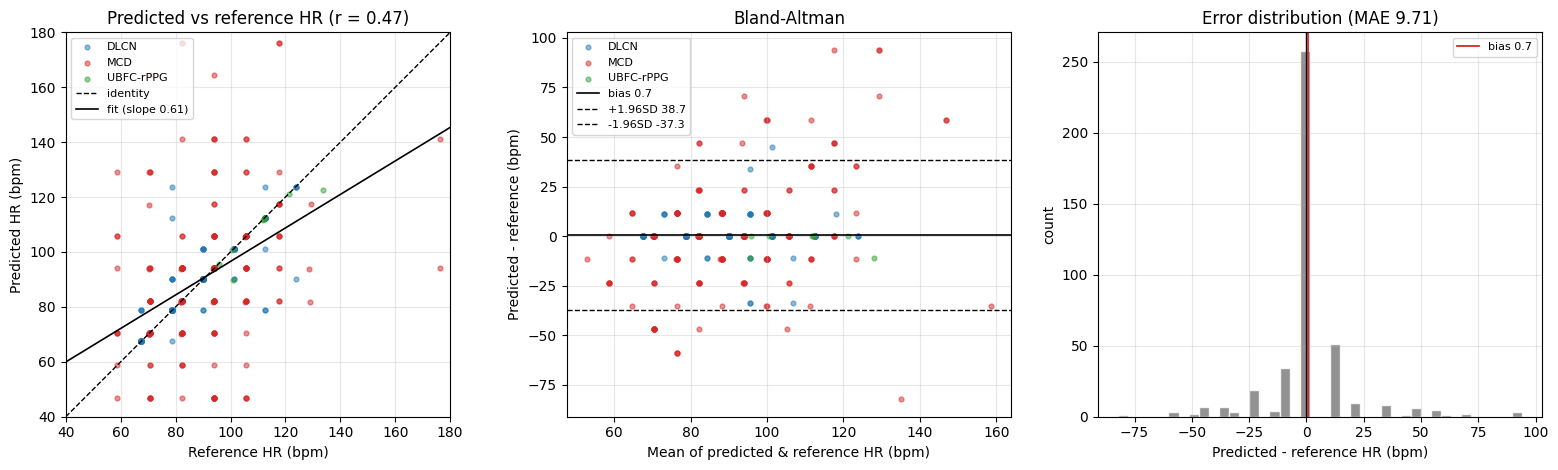

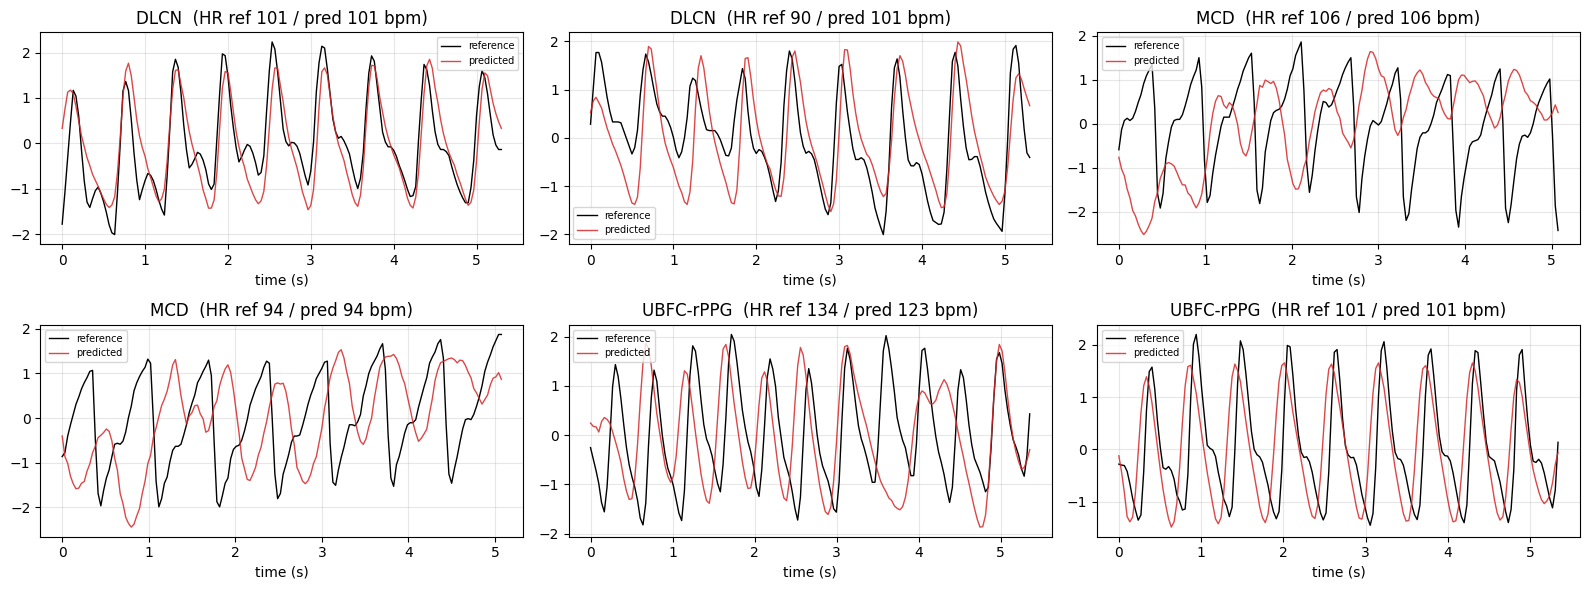

In [7]:
model.load_state_dict(torch.load('physformer_best.pt', map_location=device))
model.eval()

@torch.no_grad()
def collect_predictions(model, loader, waves_per_ds=2):
    rows, waves, wave_ct = [], [], {}
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = pf_forward(model, frames)
        pred = pred.float().cpu().numpy(); bvp = batch['bvp'].numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp))
            if wave_ct.get(ds[i], 0) < waves_per_ds:
                waves.append((ds[i], float(fps[i]), bvp[i].copy(), pred[i].copy()))
                wave_ct[ds[i]] = wave_ct.get(ds[i], 0) + 1
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred']), waves

pred_df, wave_examples = collect_predictions(model, val_loader)
print('eval clips:', len(pred_df))


def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series({'n': len(g), 'MAE': np.abs(d).mean(), 'RMSE': np.sqrt((d ** 2).mean()),
                     'bias': d.mean(), 'SD': sd, 'LoA_low': d.mean() - 1.96 * sd,
                     'LoA_high': d.mean() + 1.96 * sd,
                     'Pearson_r': np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan})


summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
overall = metrics_block(pred_df); overall.name = 'ALL'
print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

colors = {'MCD': 'tab:red', 'DLCN': 'tab:blue', 'UBFC-rPPG': 'tab:green'}
diff = (pred_df.hr_pred - pred_df.hr_true).values
bias, sd = diff.mean(), diff.std(ddof=1)
r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
lim = [40, 180]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
for ds, gdf in pred_df.groupby('dataset'):
    ax[0].scatter(gdf.hr_true, gdf.hr_pred, s=12, alpha=0.5, color=colors.get(ds, 'gray'), label=ds)
ax[0].plot(lim, lim, 'k--', lw=1, label='identity')
slope, intc = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
ax[0].plot(np.array(lim), intc + slope * np.array(lim), 'k-', lw=1.2, label=f'fit (slope {slope:.2f})')
ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR (bpm)', ylabel='Predicted HR (bpm)',
          title=f'Predicted vs reference HR (r = {r:.2f})', aspect='equal')
ax[0].legend(fontsize=8, loc='upper left'); ax[0].grid(alpha=0.3)
for ds, gdf in pred_df.groupby('dataset'):
    m = (gdf.hr_true + gdf.hr_pred) / 2; d = gdf.hr_pred - gdf.hr_true
    ax[1].scatter(m, d, s=12, alpha=0.5, color=colors.get(ds, 'gray'), label=ds)
ax[1].axhline(bias, color='k', lw=1.2, label=f'bias {bias:.1f}')
ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1, label=f'+1.96SD {bias + 1.96 * sd:.1f}')
ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1, label=f'-1.96SD {bias - 1.96 * sd:.1f}')
ax[1].set(xlabel='Mean of predicted & reference HR (bpm)', ylabel='Predicted - reference (bpm)', title='Bland-Altman')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
ax[2].axvline(0, color='k', lw=1); ax[2].axvline(bias, color='tab:red', lw=1.3, label=f'bias {bias:.1f}')
ax[2].set(xlabel='Predicted - reference HR (bpm)', ylabel='count',
          title=f'Error distribution (MAE {np.abs(diff).mean():.2f})')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
for k, (ds, fps, bt, bp) in enumerate(wave_examples[:6]):
    axr = axes[k // 3, k % 3]
    bt = (bt - bt.mean()) / (bt.std() + 1e-6); bp = (bp - bp.mean()) / (bp.std() + 1e-6)
    t = np.arange(len(bt)) / fps
    axr.plot(t, bt, color='k', lw=1.0, label='reference')
    axr.plot(t, bp, color='tab:red', lw=1.0, alpha=0.85, label='predicted')
    axr.set(title=f'{ds}  (HR ref {hr_from_bvp(bt, fps):.0f} / pred {hr_from_bvp(bp, fps):.0f} bpm)', xlabel='time (s)')
    axr.legend(fontsize=7); axr.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. SQI-gated Re-evaluation
Re-scores the trained model at increasing reference-BVP SQI thresholds, per dataset, to
separate model error from reference-label noise. Flat results across thresholds mean the
held-out references are clean and the remaining error is genuine model difficulty.

In [8]:
def clip_sqi(bvp, fps, low=0.7, high=3.5):
    '''3-bin peak-power fraction of the reference BVP = how trustworthy this clip's true-HR label is.'''
    x = np.asarray(bvp, float); x = x - x.mean()
    if x.std() < 1e-8:
        return 0.0
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return 0.0
    pk = int(np.argmax(p[b]))
    return float(p[b][max(0, pk - 1):pk + 2].sum() / p[b].sum())

FWD = lambda f: pf_forward(model, f)

@torch.no_grad()
def collect_with_sqi(model, loader, fwd):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = fwd(frames)
        pred = pred.float().cpu().numpy()
        bvp = batch['bvp'].numpy(); hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp, clip_sqi(bvp[i], float(fps[i]))))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred', 'ref_sqi'])

df = collect_with_sqi(model, val_loader, FWD)
df['ae'] = (df.hr_pred - df.hr_true).abs()
print('total eval clips:', len(df))
for thr in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]:
    sub = df[df.ref_sqi >= thr]
    if len(sub) < 5:
        continue
    r = np.corrcoef(sub.hr_true, sub.hr_pred)[0, 1] if len(sub) > 2 else float('nan')
    pds = sub.groupby('dataset')['ae'].mean().round(2).to_dict()
    print(f'ref_sqi>={thr:.2f} | n {len(sub):4d} | MAE {sub.ae.mean():5.2f} | r {r:.3f} | per-dataset {pds}')

total eval clips: 425
ref_sqi>=0.00 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.05 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.10 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.15 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.20 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.30 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}


In [9]:
def clip_sqi(bvp, fps, low=0.7, high=3.5):
    '''3-bin peak-power fraction of the reference BVP = how trustworthy this clip's true-HR label is.'''
    x = np.asarray(bvp, float); x = x - x.mean()
    if x.std() < 1e-8:
        return 0.0
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return 0.0
    pk = int(np.argmax(p[b]))
    return float(p[b][max(0, pk - 1):pk + 2].sum() / p[b].sum())

FWD = lambda f: pf_forward(model, f)

@torch.no_grad()
def collect_with_sqi(model, loader, fwd):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = fwd(frames)
        pred = pred.float().cpu().numpy()
        bvp = batch['bvp'].numpy(); hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp, clip_sqi(bvp[i], float(fps[i]))))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred', 'ref_sqi'])

df = collect_with_sqi(model, val_loader, FWD)
df['ae'] = (df.hr_pred - df.hr_true).abs()
print('total eval clips:', len(df))
for thr in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]:
    sub = df[df.ref_sqi >= thr]
    if len(sub) < 5:
        continue
    r = np.corrcoef(sub.hr_true, sub.hr_pred)[0, 1] if len(sub) > 2 else float('nan')
    pds = sub.groupby('dataset')['ae'].mean().round(2).to_dict()
    print(f'ref_sqi>={thr:.2f} | n {len(sub):4d} | MAE {sub.ae.mean():5.2f} | r {r:.3f} | per-dataset {pds}')
print(df.groupby('dataset')['ref_sqi'].describe()[['min', '25%', '50%', '75%', 'max']].round(3))

total eval clips: 425
ref_sqi>=0.00 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.05 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.10 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.15 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.20 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
ref_sqi>=0.30 | n  425 | MAE  9.71 | r 0.471 | per-dataset {'DLCN': 2.14, 'MCD': 15.93, 'UBFC-rPPG': 2.8}
             min    25%    50%    75%    max
dataset                                     
DLCN       0.442  0.759  0.813  0.856  0.991
MCD        0.361  0.685  0.786  0.837  0.990
UBFC-rPPG  0.629  0.874  0.928  0.968  0.987
